In [216]:
from PIL.ImagePalette import negative
from datasets import load_dataset
import numpy as np

In [217]:
ds = load_dataset("imdb")

In [218]:
ds

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

In [219]:
train_df = ds["train"].to_pandas()

In [220]:
train_df.sample(10)

,text,label
11451,Fairly amusing piece that tries to show how sm...,0
14982,"Vampires, sexy guys, guns and some blood. Who ...",1
11740,Three story lines and not enough tying them to...,0
21072,How I got into it: When I started watching thi...,1
3210,i like Jane Austin novels. I love Pride and Pr...,0
12410,This only gets bashed because it stars David H...,0
6796,Ever wonder why Pacific Islanders seem to auto...,0
10438,"This movie is great, mind you - but only in th...",0
9459,Marilyn Miller made only three films before he...,0
21915,If The Man in the White Suit had been done in ...,1


In [221]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [222]:
train_df['sentiment'] = np.where(train_df.label ==1,'positive',"negative")

In [223]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [224]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

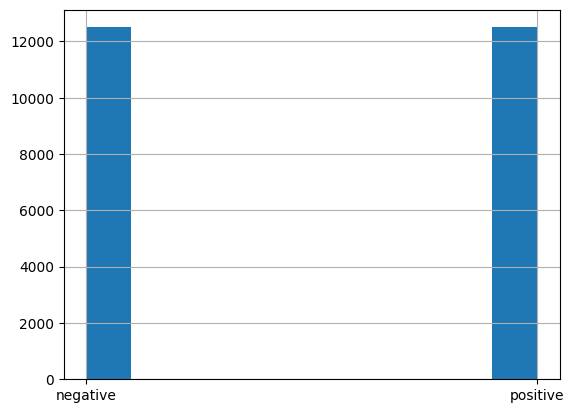

In [225]:
train_df.sentiment.hist()

In [226]:
from sklearn.model_selection import train_test_split

In [227]:
examples_df, gold_examples_df = train_test_split(
    train_df, test_size=0.2, random_state=123
)

In [228]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [229]:
columns = ['text', 'sentiment']
gold_examples = (
    gold_examples_df[columns]
    .sample(20, random_state=34)
    .to_json(orient="records")
)

In [230]:
import json

In [231]:
json.loads(gold_examples)[0]

{'text': '"A Guy Thing" may not be a classic, but it sure is a good, funny comedy. The plot focuses on Paul (Jason Lee), who wakes up the morning after his bachelor party with no memory and Becky (Julia Stiles) lying naked in his bed. Before he can figure out what happened, he rushes Becky out of his apartment because his fiance Karen (Selma Blair) is coming. After that, as you could imagine, chaos ensues.<br /><br />Almost every single scene in "A Guy Thing" delivers loud laughs. The funniest moments come from when Paul imagines what could happen if he tells Karen. Selma Blair is a truly talented comedian, and the worst thing about this film is that she goes underused. Although, she turns out to be more funny than Stiles\' character, who actually isn\'t that interesting. Of course, not every comedy is perfect.<br /><br />As I said, "A Guy Thing" is no classic, but it\'s not bad either, 7/10.',
 'sentiment': 'positive'}

In [232]:
user_prompt_template = """```{movie_review}```"""

In [233]:
zero_shot_prompt_system_message = """
Classify the sentiment of movie reviews presented in the input as positive or negative.
Movie review will be by delimited triple backticks ``` i the input.
Answer only as 'positive' or 'negative'.
Do not explain your answer.
"""

In [234]:
zero_shot_prompt = [
    {"role": "system", "content": zero_shot_prompt_system_message}
]

In [235]:
few_shot_prompt_system_message = """
Classify the sentiment of movie reviews presented in the input as positive or negative.
Movie review will be by delimited triple backticks ``` i the input.
Answer only as 'positive' or 'negative'.
Do not explain your answer.
"""

In [236]:
examples_df.shape

(20000, 3)

In [237]:
positive_reviews_df = (examples_df[examples_df['sentiment'] == 'positive'][columns]
                       .sample(4))

In [238]:
positive_reviews_df

,text,sentiment
24010,"An American in Paris was, in many ways, the ul...",positive
15521,whereas the hard-boiled detective stories of D...,positive
22038,This couldn't have been better. The strong res...,positive
24420,Thought at first this film would be your typic...,positive


In [239]:
negative_reviews_df = (examples_df[examples_df['sentiment'] == 'negative'][columns]
                       .sample(4))

In [240]:
negative_reviews_df

,text,sentiment
4815,"Beautiful attracts excellent idea, but ruined ...",negative
9062,Previous comments encouraged me to check this ...,negative
10701,This ranks as one of the worst movies I've see...,negative
5956,This is one of the most hateful and cruel movi...,negative


In [241]:
positive_reviews_df.shape, negative_reviews_df.shape

((4, 2), (4, 2))

In [242]:
import pandas as pd

In [243]:
ex_df = pd.concat([positive_reviews_df, negative_reviews_df])

In [244]:
ex_df

,text,sentiment
24010,"An American in Paris was, in many ways, the ul...",positive
15521,whereas the hard-boiled detective stories of D...,positive
22038,This couldn't have been better. The strong res...,positive
24420,Thought at first this film would be your typic...,positive
4815,"Beautiful attracts excellent idea, but ruined ...",negative
9062,Previous comments encouraged me to check this ...,negative
10701,This ranks as one of the worst movies I've see...,negative
5956,This is one of the most hateful and cruel movi...,negative


In [245]:
examples = examples_df.sample(4*2, replace=False).to_json(orient="records")

In [246]:
examples

'[{"text":"i thought this movie was wonderfully plotted it made me confused and my cousin who watched it with me.to tell the truth i think that the younger kevin dillon was hot.hahahaha...but i also thought the girl was stupid to go along with the cop and that was wrong what he said to her before his death\\"i was inside you\\".i think that\'s what she gets for doing what she did with him and how is he going to tell her that she\'s too young when he never cared how old the other girls were.?now i don\'t think i myself could ever trust a cop like that.but to tell the truth it was pretty obvious it was him even if he was wanting to become a cop i would still be suspicious of him either way.and that was funny when she sprayed him in the eye in the store.hahahahaha.she was still stupid for going into the warehouse again by herself and so was the cop who died HELLO!! it\'s called back-up.sometimes these movies make me mad when people act stupid and do stupid things.but that\'s what i think 

In [247]:
def create_examples(dataset, n=4):
    positive_reviews_df = (dataset[dataset['sentiment'] == 'positive'][columns]
                       .sample(n))
    negative_reviews_df = (dataset[dataset['sentiment'] == 'negative'][columns]
                       .sample(n))
    examples_df = pd.concat([positive_reviews_df, negative_reviews_df])
    examples = examples_df.sample(2*n, replace=False).to_json(orient="records")
    return examples

In [248]:
examples_df.shape

(20000, 3)

In [249]:
few_shot_examples = create_examples(examples_df, n=2)

In [250]:
json.loads(few_shot_examples)

[{'text': 'I saw this piece of garbage on AMC last night, and wonder how it could be considered in any way an American Movie Classic. It was awful in every way. How badly did Jack Lemmon, James Stewart and the rest of the cast need cash that they would even consider doing this movie?',
  'sentiment': 'negative'},
 {'text': "Huge, exhaustive and passionate summary of American cinema as seen through the eyes of Martin Scorcese. Needless to say, there is never a dull moment in all of its 4 hour running time. Many genres, periods and directors are all examined, discussed more from the perspective of cinephile rather than contemporary director. For anyone even remotely interested in American films, or cinema in general. A masterpiece, and the best of the BFI's Century of Cinema series.<br /><br />",
  'sentiment': 'positive'},
 {'text': "I first saw this when I was around 7. I remembered what I believed to be a vague outline of what took place. Turns out now, 15 years later, that I remember

In [251]:
def create_prompt(system_message, examples, user_prompt_template):

    prompt = [{"role": "system", "content": system_message}]

    for example in json.loads(examples):

        review = example['text']
        sentiment = example['sentiment']

        prompt.append({"role": "user", "content": user_prompt_template.format(movie_review=review)})
        prompt.append({"role": "assistant", "content": f"{sentiment}"})

    return prompt

In [252]:
few_shot_prompt = create_prompt(few_shot_prompt_system_message, few_shot_examples, user_prompt_template)

In [253]:
few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as positive or negative.\nMovie review will be by delimited triple backticks ``` i the input.\nAnswer only as 'positive' or 'negative'.\nDo not explain your answer.\n"},
 {'role': 'user',
  'content': '```I saw this piece of garbage on AMC last night, and wonder how it could be considered in any way an American Movie Classic. It was awful in every way. How badly did Jack Lemmon, James Stewart and the rest of the cast need cash that they would even consider doing this movie?```'},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': "```Huge, exhaustive and passionate summary of American cinema as seen through the eyes of Martin Scorcese. Needless to say, there is never a dull moment in all of its 4 hour running time. Many genres, periods and directors are all examined, discussed more from the perspective of cinephile rather than contemporary director. For anyone e

In [254]:
chain_of_thought_few_shot_prompt_system_message = """
Classify the sentiment of movie reviews presented in the input as positive or negative.
Movie review will be by delimited triple backticks ``` i the input.
Answer only as 'positive' or 'negative'.
Do not explain your answer.

Instructions:
1. Carefully read the text of the review and think through the option for sentiment provided.
2. Consider the overall sentiment of the review and estimate the probability of the review being positive or negative.
3. Provide your final answer as label 'positive' or 'negative' based on your analysis.
"""

In [255]:
cot_few_shot_prompt = create_prompt(chain_of_thought_few_shot_prompt_system_message, few_shot_examples, user_prompt_template)

In [256]:
cot_few_shot_prompt

[{'role': 'system',
  'content': "\nClassify the sentiment of movie reviews presented in the input as positive or negative.\nMovie review will be by delimited triple backticks ``` i the input.\nAnswer only as 'positive' or 'negative'.\nDo not explain your answer.\n\nInstructions:\n1. Carefully read the text of the review and think through the option for sentiment provided.\n2. Consider the overall sentiment of the review and estimate the probability of the review being positive or negative.\n3. Provide your final answer as label 'positive' or 'negative' based on your analysis.\n"},
 {'role': 'user',
  'content': '```I saw this piece of garbage on AMC last night, and wonder how it could be considered in any way an American Movie Classic. It was awful in every way. How badly did Jack Lemmon, James Stewart and the rest of the cast need cash that they would even consider doing this movie?```'},
 {'role': 'assistant', 'content': 'negative'},
 {'role': 'user',
  'content': "```Huge, exhausti

In [257]:
from sklearn.metrics import f1_score

In [258]:
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm_model, log=True):

    predicted_sentiments = []
    ground_truth_sentiments = []

    for example in json.loads(gold_examples):

        review = example['text']
        sentiment = example['sentiment']

        user_input = [{"role": "user", "content": user_prompt_template.format(movie_review=review)}]

        try:
            response = llm_model.invoke(prompt+user_input)
            if 'negative' in response.content.strip().lower():
                predicted_sentiment = 'negative'
            elif 'positive' in response.content.strip().lower():
                predicted_sentiment = 'positive'
            else:
                predicted_sentiment = 'unknown'

            predicted_sentiments.append(predicted_sentiment)
            ground_truth_sentiments.append(sentiment)

            if log:
                print(predicted_sentiment, sentiment)

        except Exception as e:
            print(f"Error: {e}")
            continue
    return f1_score(ground_truth_sentiments, predicted_sentiments, average='micro')

In [259]:
from dotenv import load_dotenv
load_dotenv(override=True)

True

In [260]:
from langchain_openai import ChatOpenAI

In [261]:
llm1 = ChatOpenAI(model="gpt-4o", temperature=0)

In [262]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [263]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template, llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [264]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template, llm1)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [265]:
from langchain_ollama import ChatOllama

In [266]:
llm2 = ChatOllama(model="gemma3:1b", temperature=0)

In [267]:
evaluate_prompt(zero_shot_prompt, gold_examples, user_prompt_template, llm2)

positive positive
negative negative
negative positive
negative positive
positive positive
negative positive
negative negative
negative negative
negative negative
negative positive
positive positive
negative negative
negative negative
negative positive
negative positive
positive positive
negative negative
negative positive
negative positive
negative negative


0.6

In [268]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template, llm2)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
positive positive
positive positive
positive positive
negative negative
negative positive
negative positive
negative negative


0.9

In [269]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template, llm2)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
positive positive
positive positive
positive positive
negative negative
negative positive
negative positive
negative negative


0.9

In [270]:
llm3 = ChatOpenAI(model="gpt-5.2", temperature=0)

In [271]:
evaluate_prompt(cot_few_shot_prompt, gold_examples, user_prompt_template, llm3)

positive positive
negative negative
positive positive
positive positive
positive positive
positive positive
negative negative
negative negative
negative negative
positive positive
positive positive
negative negative
negative negative
negative positive
positive positive
positive positive
negative negative
positive positive
positive positive
negative negative


0.95

In [272]:
from tqdm import tqdm

In [273]:
llm_model = llm2
performances = []
num_eval_runs=5
n=4

for _ in tqdm(range(num_eval_runs)):
    examples = create_examples(examples_df, n=n)
    few_shot_prompt_message = create_prompt(few_shot_prompt_system_message, examples, user_prompt_template)
    score = evaluate_prompt(few_shot_prompt_message, gold_examples, user_prompt_template, llm_model, False)
    performances.append(score)

mean = np.array(performances).mean()
std = np.array(performances).std()

print(f"Mean F1 Score: {mean:.4f}, Std Dev: {std:.4f}")

100%|██████████| 5/5 [02:34<00:00, 30.84s/it]

Mean F1 Score: 0.7100, Std Dev: 0.1562
